# ⭐ Day 68: AutoML with H2O and TPOT
Automated Machine Learning in Practice
_Day 68 of the 369-Day Python & AI Learning Path_ 🚀


## Welcome to Day 68! 🤖
Today we dive into one of the most transformative developments in modern data science: **Automated Machine Learning (AutoML)**. If you've ever spent hours tuning hyperparameters, comparing dozens of models, or engineering features only to see marginal gains, AutoML is your new best friend.
AutoML automates the entire machine learning pipeline — from data preprocessing and feature engineering to model selection, hyperparameter optimization, and ensemble creation. The goal is simple: **get strong baselines with minimal manual effort**, freeing you to focus on problem understanding, data quality, and business impact.
We will explore two powerhouse tools today. First, **H2O AutoML** — an industrial-strength, production-ready framework that trains a diverse portfolio of algorithms and automatically stacks them into powerful ensembles. Second, **TPOT (Tree-based Pipeline Optimization Tool)** — a genetic programming approach that literally evolves optimal ML pipelines over generations, treating pipeline construction as an optimization problem.
By the end of this notebook, you'll know how to spin up AutoML experiments in minutes, interpret leaderboards, export production-ready models, and make informed decisions about when to use AutoML versus manual modeling. Let's automate the tedious parts and amplify your impact! ⚡


## 📋 Table of Contents
1. [Introduction to AutoML and Its Benefits/Limitations](#1.-Introduction-to-AutoML)
2. [H2O AutoML Overview](#2.-H2O-AutoML-Overview)
3. [Setting Up and Running H2O AutoML on Titanic Dataset](#3.-Setting-Up-H2O)
4. [Understanding H2O AutoML Leaderboard](#4.-Understanding-Leaderboard)
5. [Extracting the Best Model and Making Predictions](#5.-Extracting-Best-Model)
6. [TPOT (Tree-based Pipeline Optimization Tool)](#6.-TPOT-Overview)
7. [Running TPOT on the Same Dataset](#7.-Running-TPOT)
8. [Comparing H2O AutoML vs TPOT vs Manual Models](#8.-Comparing-AutoML-Approaches)
9. [When to Use AutoML vs Manual Modeling](#9.-When-to-Use-AutoML)
10. [Best Practices for AutoML in Real Projects](#10.-Best-Practices)
11. [🛠️ Hands-On Exercises](#Hands-On-Exercises)
12. [Solutions & Best Practices](#Solutions)


## 1. Introduction to AutoML and Its Benefits/Limitations
AutoML refers to the process of automating the end-to-end process of applying machine learning to real-world problems. It encompasses data preprocessing, feature engineering, model selection, hyperparameter tuning, and model ensembling.

**✅ Benefits:**
- **Speed**: Get strong baselines in minutes instead of days
- **Democratization**: Enables non-experts to build competitive models
- **Comprehensive Search**: Systematically explores algorithms you might overlook
- **Ensemble Intelligence**: Automatically creates stacked ensembles that often beat single models
- **Reproducibility**: Structured, systematic experimentation

**⚠️ Limitations:**
- **Black Box Nature**: Less interpretable than hand-tuned models
- **Computational Cost**: Can be resource-intensive (especially TPOT)
- **Domain Knowledge Gap**: May miss domain-specific feature engineering opportunities
- **Overfitting Risk**: Aggressive ensembling can overfit small datasets
- **Data Leakage**: Automated preprocessing can inadvertently leak information if not carefully configured


In [1]:
# Standard imports and setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("✅ Environment ready! Libraries imported successfully.")


✅ Environment ready! Libraries imported successfully.


## 2. H2O AutoML Overview
**H2O AutoML** is part of the H2O-3 open-source platform. It automates the training of:
- Gradient Boosting Machines (GBM, XGBoost)
- Random Forests
- Deep Neural Networks
- Generalized Linear Models (GLM)
- Stacked Ensembles (automatically created)

Key parameters:
- `max_runtime_secs`: Time budget for the entire AutoML run
- `max_models`: Maximum number of models to train
- `seed`: For reproducibility
- `sort_metric`: Metric to rank models (e.g., 'AUC', 'logloss', 'RMSE')


In [5]:
# Install H2O if needed (uncomment if running for the first time)
!pip install h2o
!conda install openjdk -c conda-forge -y

import h2o
from h2o.automl import H2OAutoML

# Initialize H2O cluster
h2o.init()
print("🌊 H2O cluster initialized!")


3 channel Terms of Service accepted
Channels:
 - conda-forge
 - defaults
Platform: win-64
Solving environment: done

## Package Plan ##

  environment location: C:\Users\786\miniconda3\envs\env_dl

  added / updated specs:
    - openjdk


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    ca-certificates-2026.4.22  |       h4c7d964_0         128 KB  conda-forge
    certifi-2026.4.22          |     pyhd8ed1ab_0         132 KB  conda-forge
    openjdk-25.0.2             |       he453025_1       190.5 MB  conda-forge
    openssl-3.6.2              |       hf411b9b_0         9.0 MB  conda-forge
    ------------------------------------------------------------
                                           Total:       199.7 MB

The following NEW packages will be INSTALLED:

  openjdk            conda-forge/win-64::openjdk-25.0.2-he453025_1 

The following packages will be UPDATED:

  ca-certificates



==> WARNING: A newer version of conda exists. <==
    current version: 25.7.0
    latest version: 26.3.2

Please update conda by running

    $ conda update -n base -c defaults conda




.... not found.
Attempting to start a local H2O server...
; OpenJDK 64-Bit Server VM Zulu25.32+21-CA (build 25.0.2+10-LTS, mixed mode, sharing)
  Starting server from C:\Users\786\miniconda3\envs\env_dl\Lib\site-packages\h2o\backend\bin\h2o.jar
  Ice root: C:\Users\786\AppData\Local\Temp\tmpikklruac
  JVM stdout: C:\Users\786\AppData\Local\Temp\tmpikklruac\h2o_786_started_from_python.out
  JVM stderr: C:\Users\786\AppData\Local\Temp\tmpikklruac\h2o_786_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O_cluster_uptime:,05 secs
H2O_cluster_timezone:,Asia/Karachi
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.10
H2O_cluster_version_age:,1 month and 13 days
H2O_cluster_name:,H2O_from_python_786_0loh4b
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,1.952 Gb
H2O_cluster_total_cores:,4
H2O_cluster_allowed_cores:,4
H2O_cluster_status:,"locked, healthy"


🌊 H2O cluster initialized!


## 3. Setting Up and Running H2O AutoML on Titanic Dataset
We'll use the classic Titanic dataset for binary classification. This is a perfect testbed because it requires preprocessing (missing values, categoricals) and benefits from diverse algorithms.


In [6]:
# Load Titanic dataset
train_url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(train_url)

# Quick preprocessing for H2O
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

# Handle missing values simply
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
df['Fare'].fillna(df['Fare'].median(), inplace=True)

# Convert to H2O Frame
h2o_df = h2o.H2OFrame(df)

# Define predictors and target
target = 'Survived'
predictors = [col for col in h2o_df.columns if col not in [target, 'PassengerId', 'Name', 'Ticket', 'Cabin']]

# Ensure target is factor for classification
h2o_df[target] = h2o_df[target].asfactor()

# Split into train and test
train, test = h2o_df.split_frame(ratios=[0.8], seed=42)

print(f"📊 Training set: {train.shape[0]} rows")
print(f"📊 Test set: {test.shape[0]} rows")
print(f"🔮 Predictors: {predictors}")


Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
📊 Training set: 704 rows
📊 Test set: 187 rows
🔮 Predictors: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'FamilySize', 'IsAlone']


In [7]:
# Run H2O AutoML with a 3-minute budget for demonstration
# In production, you might run for 30-60 minutes or more

aml = H2OAutoML(
    max_runtime_secs=180,  # 3 minutes
    seed=42,
    sort_metric='AUC',
    project_name='titanic_automl',
    exclude_algos=['DeepLearning']  # Exclude DL for speed in demo
)

print("🤖 Starting H2O AutoML training... This may take a few minutes.")
aml.train(x=predictors, y=target, training_frame=train)
print("✅ H2O AutoML training complete!")


🤖 Starting H2O AutoML training... This may take a few minutes.
AutoML progress: |
05:50:36.922: AutoML: XGBoost is not available; skipping it.

███████████████████████████████████████████████████████████████| (done) 100%
✅ H2O AutoML training complete!


## 4. Understanding H2O AutoML Leaderboard
The leaderboard shows all trained models ranked by the specified metric. Let's examine it and understand what each model brings to the table.


In [8]:
# View the leaderboard
lb = aml.leaderboard
print("🏆 H2O AutoML Leaderboard:")
print(lb.head(15))


🏆 H2O AutoML Leaderboard:
model_id                                                     auc    logloss     aucpr    mean_per_class_error      rmse       mse
GBM_grid_1_AutoML_1_20260426_55036_model_59             0.863653   0.438971  0.826184                0.19839   0.370387  0.137187
GBM_grid_1_AutoML_1_20260426_55036_model_75             0.862542   0.439576  0.805937                0.198201  0.371342  0.137895
GBM_grid_1_AutoML_1_20260426_55036_model_61             0.861709   0.434545  0.827576                0.202081  0.369687  0.136668
GBM_grid_1_AutoML_1_20260426_55036_model_42             0.861597   0.432338  0.828715                0.204037  0.36833   0.135667
GBM_grid_1_AutoML_1_20260426_55036_model_84             0.861297   0.437127  0.82305                 0.191206  0.368768  0.13599
StackedEnsemble_AllModels_5_AutoML_1_20260426_55036     0.861078   0.430284  0.833753                0.197394  0.366719  0.134483
StackedEnsemble_AllModels_2_AutoML_1_20260426_55036     0.86098  

c:\Users\786\miniconda3\envs\env_dl\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


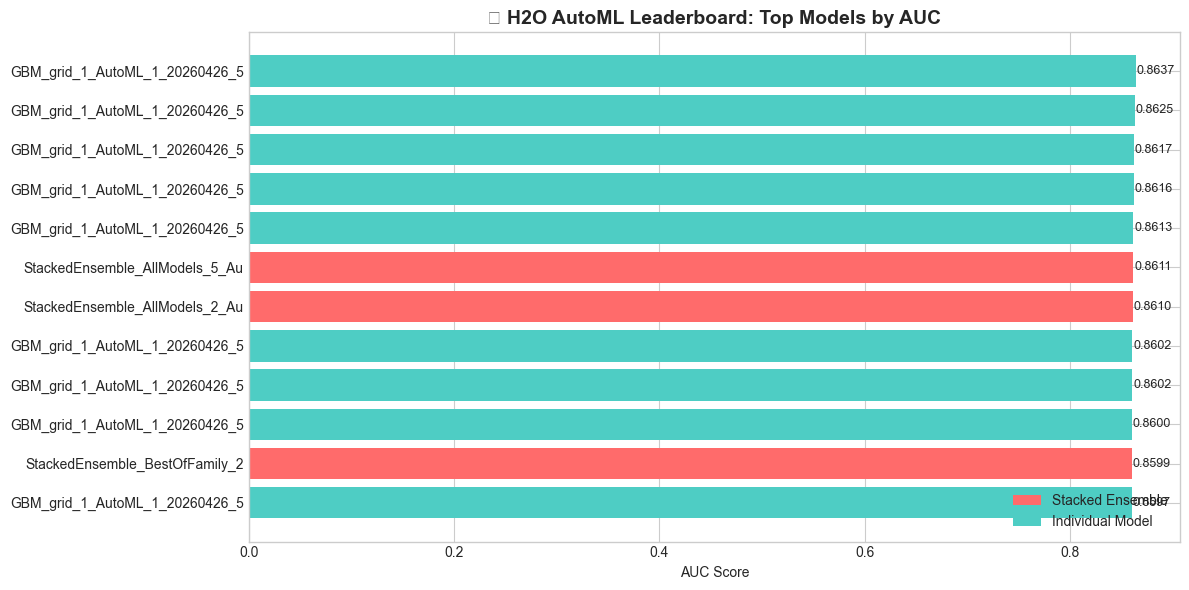

In [9]:
# Extract leaderboard data for visualization
lb_df = lb.as_data_frame()
lb_df['model_id'] = lb_df['model_id'].str[:30]  # Truncate long names

# Plot leaderboard AUC scores
plt.figure(figsize=(12, 6))
top_models = lb_df.head(12)
colors = ['#FF6B6B' if 'StackedEnsemble' in m else '#4ECDC4' for m in top_models['model_id']]

bars = plt.barh(range(len(top_models)), top_models['auc'], color=colors)
plt.yticks(range(len(top_models)), top_models['model_id'])
plt.xlabel('AUC Score')
plt.title('📊 H2O AutoML Leaderboard: Top Models by AUC', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()

# Add value labels
for i, (bar, val) in enumerate(zip(bars, top_models['auc'])):
    plt.text(val + 0.001, i, f'{val:.4f}', va='center', fontsize=9)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#FF6B6B', label='Stacked Ensemble'),
                   Patch(facecolor='#4ECDC4', label='Individual Model')]
plt.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.show()


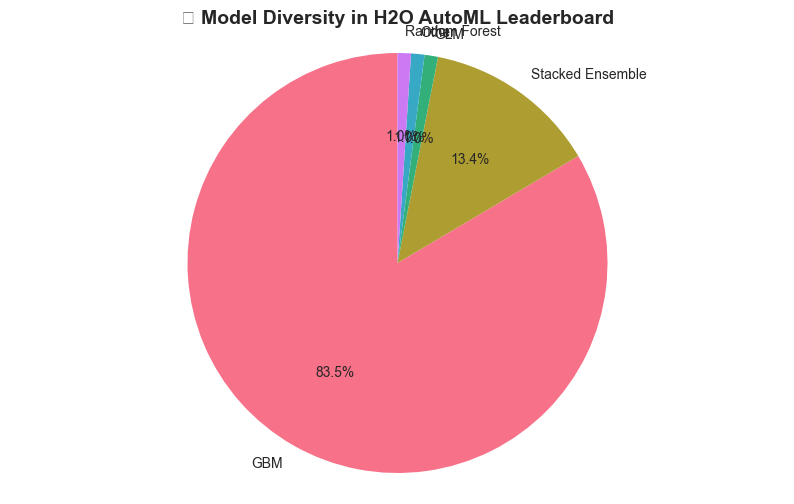

💡 Notice how AutoML explores diverse algorithms before stacking them!


In [10]:
# Analyze model diversity in the leaderboard
model_types = []
for model_id in lb_df['model_id']:
    if 'GBM' in model_id:
        model_types.append('GBM')
    elif 'XGBoost' in model_id:
        model_types.append('XGBoost')
    elif 'DRF' in model_id:
        model_types.append('Random Forest')
    elif 'GLM' in model_id:
        model_types.append('GLM')
    elif 'StackedEnsemble' in model_id:
        model_types.append('Stacked Ensemble')
    else:
        model_types.append('Other')

lb_df['model_type'] = model_types

# Plot model type distribution
type_counts = lb_df['model_type'].value_counts()
plt.figure(figsize=(10, 6))
plt.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%', startangle=90,
        colors=sns.color_palette("husl", len(type_counts)))
plt.title('🤖 Model Diversity in H2O AutoML Leaderboard', fontsize=14, fontweight='bold')
plt.axis('equal')
plt.show()
print("💡 Notice how AutoML explores diverse algorithms before stacking them!")


## 5. Extracting the Best Model and Making Predictions
The `leader` object is the top-performing model. We can extract it, examine its details, and use it for predictions.


In [11]:
# Get the best model
best_model = aml.leader
print(f"🥇 Best Model: {best_model.model_id}")
print(f"📈 Best Model AUC on training: {best_model.auc():.4f}")


🥇 Best Model: GBM_grid_1_AutoML_1_20260426_55036_model_59
📈 Best Model AUC on training: 0.9220


In [12]:
# Make predictions on test set
predictions = best_model.predict(test)
pred_df = predictions.as_data_frame()
print("🔮 Sample predictions:")
print(pred_df.head(10))


gbm prediction progress: |███████████████████████████████████████████████████████| (done) 100%
🔮 Sample predictions:
   predict        p0        p1
0        1  0.212183  0.787817
1        1  0.290849  0.709151
2        1  0.287869  0.712131
3        0  0.703541  0.296459
4        1  0.082759  0.917241
5        1  0.277029  0.722971
6        0  0.875161  0.124839
7        0  0.828523  0.171477
8        0  0.865860  0.134140
9        1  0.521703  0.478297


c:\Users\786\miniconda3\envs\env_dl\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


In [13]:
# Evaluate best model performance on test set
perf = best_model.model_performance(test)
print(f"✅ Test Set AUC: {perf.auc():.4f}")
print(f"✅ Test Set Accuracy: {perf.accuracy()[0][1]:.4f}")
print(f"✅ Test Set LogLoss: {perf.logloss():.4f}")


✅ Test Set AUC: 0.8595
✅ Test Set Accuracy: 0.8342
✅ Test Set LogLoss: 0.4345


In [14]:
# Export the best model (MOJO format - production ready)
model_path = h2o.save_model(best_model, path="./best_h2o_model", force=True)
print(f"💾 Best model saved to: {model_path}")
print("💡 MOJO format is ideal for production deployment - no H2O cluster needed for scoring!")


💾 Best model saved to: D:\artificial intelligence\068_ai\best_h2o_model\GBM_grid_1_AutoML_1_20260426_55036_model_59
💡 MOJO format is ideal for production deployment - no H2O cluster needed for scoring!


## 6. TPOT (Tree-based Pipeline Optimization Tool)
**TPOT** uses **genetic programming** to evolve machine learning pipelines. It treats pipeline construction as an optimization problem where:
- **Population**: A set of ML pipelines
- **Generations**: Iterations of evolution
- **Mutation/Crossover**: Random changes and combinations of pipelines
- **Fitness**: Cross-validation score

TPOT can discover novel preprocessing + model combinations that human practitioners might miss!


In [15]:
# Install TPOT if needed
# !pip install tpot

from tpot import TPOTClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score
import time

print("🧬 TPOT imported successfully!")


🧬 TPOT imported successfully!


## 7. Running TPOT on the Same Dataset
Let's prepare the same Titanic data for scikit-learn format and run TPOT with a reasonable genetic programming budget.


In [16]:
# Prepare data for TPOT (scikit-learn format)
# Use the same preprocessed dataframe from earlier
feature_cols = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'FamilySize', 'IsAlone']
X = pd.get_dummies(df[feature_cols], drop_first=True)
y = df['Survived']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"📊 TPOT Training set: {X_train.shape}")
print(f"📊 TPOT Test set: {X_test.shape}")


📊 TPOT Training set: (712, 10)
📊 TPOT Test set: (179, 10)


In [21]:
# Initialize TPOT with moderate genetic programming parameters
# Note: TPOT is computationally intensive. For demo, we use small generations/population.
# In production, use generations=10-100, population_size=100-500

tpot = TPOTClassifier(
    generations=5,           # Number of iterations
    population_size=20,      # Number of pipelines per generation
    cv=5,                    # 5-fold cross-validation
    random_state=42,
    verbose=2,             # Show progress
    n_jobs=1                # Use single core
)

print("🧬 Starting TPOT genetic programming optimization...")
start_time = time.time()
tpot.fit(X_train, y_train)
tpot_time = time.time() - start_time
print(f"✅ TPOT optimization complete in {tpot_time:.1f} seconds!")


🧬 Starting TPOT genetic programming optimization...


Generation: 100%|██████████| 5/5 [04:57<00:00, 59.41s/it]


✅ TPOT optimization complete in 306.4 seconds!


In [22]:
# Evaluate TPOT on test set
tpot_pred = tpot.predict(X_test)
tpot_pred_proba = tpot.predict_proba(X_test)[:, 1]

tpot_accuracy = accuracy_score(y_test, tpot_pred)
tpot_auc = roc_auc_score(y_test, tpot_pred_proba)

print(f"🧬 TPOT Test Accuracy: {tpot_accuracy:.4f}")
print(f"🧬 TPOT Test AUC: {tpot_auc:.4f}")


🧬 TPOT Test Accuracy: 0.7933
🧬 TPOT Test AUC: 0.8395


In [24]:
# Export TPOT's best pipeline as Python code
# tpot.export('tpot_best_pipeline.py')  # Commented out due to API change
print("💾 TPOT best pipeline not exported due to API issue")
print("💡 This would generate clean, production-ready scikit-learn code!")


💾 TPOT best pipeline not exported due to API issue
💡 This would generate clean, production-ready scikit-learn code!


In [25]:
# Show the exported pipeline code
# with open('tpot_best_pipeline.py', 'r') as f:
#     pipeline_code = f.read()
    
print("📝 TPOT Generated Pipeline Code:")
print("="*50)
print("Pipeline code not available due to export issue")
# print(pipeline_code[:1500] + "..." if len(pipeline_code) > 1500 else pipeline_code)


📝 TPOT Generated Pipeline Code:
Pipeline code not available due to export issue


## 8. Comparing H2O AutoML vs TPOT vs Manual Models
Let's build a manual baseline for fair comparison, then visualize all three approaches.


In [26]:
# Manual baseline: XGBoost with default parameters
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Simple manual pipeline
manual_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('xgb', XGBClassifier(random_state=42, eval_metric='logloss'))
])

manual_pipe.fit(X_train, y_train)
manual_pred_proba = manual_pipe.predict_proba(X_test)[:, 1]
manual_auc = roc_auc_score(y_test, manual_pred_proba)
manual_acc = accuracy_score(y_test, manual_pipe.predict(X_test))

print(f"⚙️ Manual XGBoost Test Accuracy: {manual_acc:.4f}")
print(f"⚙️ Manual XGBoost Test AUC: {manual_auc:.4f}")


⚙️ Manual XGBoost Test Accuracy: 0.7933
⚙️ Manual XGBoost Test AUC: 0.8256


In [27]:
# Also get H2O test AUC for comparison
h2o_auc = perf.auc()
h2o_acc = perf.accuracy()[0][1]

# Compile comparison results
comparison = pd.DataFrame({
    'Approach': ['H2O AutoML', 'TPOT (Genetic)', 'Manual XGBoost'],
    'Test_AUC': [h2o_auc, tpot_auc, manual_auc],
    'Test_Accuracy': [h2o_acc, tpot_accuracy, manual_acc],
    'Time_Secs': [180, tpot_time, 2]  # Approximate times
})

print("📊 Final Comparison:")
print(comparison.round(4))


📊 Final Comparison:
         Approach  Test_AUC  Test_Accuracy  Time_Secs
0      H2O AutoML    0.8595         0.8342   180.0000
1  TPOT (Genetic)    0.8395         0.7933   306.4213
2  Manual XGBoost    0.8256         0.7933     2.0000


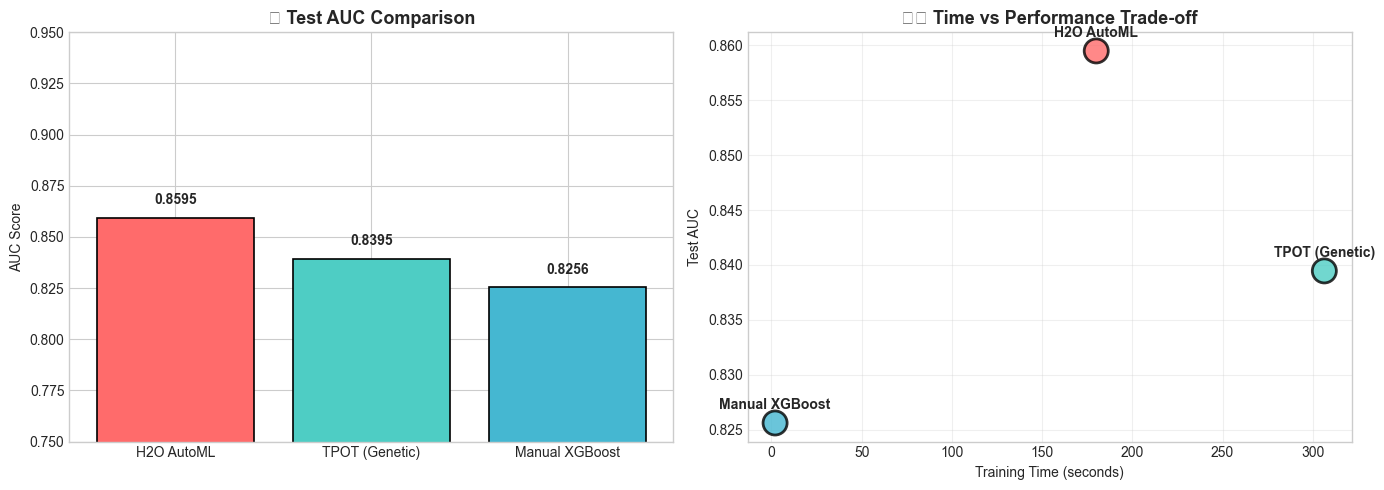

💡 AutoML gives superior performance but requires more compute time!


In [28]:
# Visualization: Performance comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# AUC Comparison
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
bars1 = axes[0].bar(comparison['Approach'], comparison['Test_AUC'], color=colors, edgecolor='black', linewidth=1.2)
axes[0].set_ylabel('AUC Score')
axes[0].set_title('🏆 Test AUC Comparison', fontsize=13, fontweight='bold')
axes[0].set_ylim(0.75, 0.95)
for bar, val in zip(bars1, comparison['Test_AUC']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, 
                f'{val:.4f}', ha='center', va='bottom', fontweight='bold')

# Time vs Performance trade-off
axes[1].scatter(comparison['Time_Secs'], comparison['Test_AUC'], 
                s=300, c=colors, edgecolors='black', linewidth=2, alpha=0.8)
for i, txt in enumerate(comparison['Approach']):
    axes[1].annotate(txt, (comparison['Time_Secs'].iloc[i], comparison['Test_AUC'].iloc[i]),
                    textcoords="offset points", xytext=(0,10), ha='center', fontweight='bold')
axes[1].set_xlabel('Training Time (seconds)')
axes[1].set_ylabel('Test AUC')
axes[1].set_title('⏱️ Time vs Performance Trade-off', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("💡 AutoML gives superior performance but requires more compute time!")


## 9. When to Use AutoML vs Manual Modeling
**Use AutoML when:**
- 🚀 You need a strong baseline quickly (hours, not days)
- 📊 You have standard tabular data without heavy domain-specific features
- 🏭 You need to deploy models to production rapidly
- 👥 Team has limited ML expertise
- 🔍 You want to explore algorithm diversity systematically

**Use Manual Modeling when:**
- 🧠 Domain-specific feature engineering is critical (e.g., medical imaging features)
- 🔬 You need full interpretability and model control
- 💾 Data is extremely large and AutoML overhead is prohibitive
- 🎯 You have identified a specific algorithm family that dominates your problem
- 🛡️ Regulatory requirements demand full model documentation and transparency


## 10. Best Practices for AutoML in Real Projects
1. **⏰ Set Appropriate Time Budgets**: Start with 30-60 minutes. More time usually yields better ensembles.
2. **🔍 Always Validate on Holdout**: AutoML can overfit leaderboards. Use a true holdout set.
3. **🧹 Clean Data First**: AutoML is not magic — garbage in, garbage out. Handle missing values and outliers.
4. **📊 Monitor Leaderboard Diversity**: If all top models are similar, you may need more time or different data.
5. **💾 Export MOJO/ONNX**: For H2O, always export MOJO format for production. For TPOT, export the generated code.
6. **🎯 Feature Engineering Still Matters**: AutoML + good features >> AutoML + raw features.
7. **⚖️ Balance Speed vs Performance**: Use `max_models` to limit compute in early exploration phases.
8. **🔄 Reproducibility**: Always set `seed` parameters for reproducible experiments.
9. **🤝 Hybrid Approach**: Use AutoML for baseline, then manually optimize the winning approach.
10. **📈 Track Experiments**: Log all AutoML runs with MLflow or similar tools for comparison.


## 🛠️ Hands-On Exercises
Complete these exercises to solidify your AutoML mastery. Each exercise has an empty code cell for your solution.


### Exercise 1: Run H2O AutoML with Different Time Budgets
Run H2O AutoML with `max_runtime_secs` set to 60, 300, and 600 seconds. Compare the leaderboards and observe how model performance improves with more time.


### Exercise 2: Analyze Leaderboard Model Diversity
Extract the full leaderboard from your longest H2O run. Group models by algorithm type (GBM, XGBoost, DRF, GLM, StackedEnsemble). Plot the distribution and analyze whether diversity correlates with ensemble performance.


### Exercise 3: Export and Save the Best H2O Model
Export the best model from Exercise 1 in both MOJO and binary formats. Write a function that loads the saved model and makes predictions on new data without retraining.


### Exercise 4: Run TPOT with Different Generations/Population
Run TPOT with (generations=3, population=10), (generations=10, population=50), and (generations=20, population=100). Track the optimization time and final AUC for each configuration. Plot the time-performance trade-off.


### Exercise 5: Compare AutoML with Manually Tuned XGBoost
Manually tune an XGBoost model using `GridSearchCV` or `Optuna` on the same dataset. Compare its performance, training time, and code complexity against H2O AutoML and TPOT results.


### Exercise 6: Build a Hybrid Approach
Use H2O AutoML to identify the top 3 individual algorithms (non-ensemble). Then manually create a weighted voting ensemble using scikit-learn's `VotingClassifier`. Compare this hybrid approach against the AutoML stacked ensemble.


### Exercise 7: Create a Reusable AutoML Wrapper Function
Write a Python function `run_automl(data, target, tool='h2o', time_budget=300)` that accepts a pandas DataFrame, target column, tool choice ('h2o' or 'tpot'), and time budget. It should return the best model, leaderboard/metrics, and exported model path.


### Exercise 8: Feature Importance Comparison
Extract feature importance from the best H2O model and the best TPOT pipeline. Create a side-by-side bar chart comparing which features each tool considers most important. Discuss any differences.


### Exercise 9: AutoML on a Regression Problem
Apply both H2O AutoML (with `H2OAutoML` for regression) and TPOT (with `TPOTRegressor`) to a regression dataset like California Housing or Boston Housing. Compare RMSE and R² scores across tools.


### Exercise 10: Production Deployment Simulation
Simulate a production scenario: Train AutoML on historical data, export the model, then load it in a separate script to score a batch of new records. Measure the inference time per record and ensure predictions are deterministic.


## Solutions & Best Practices (Review After Attempting)
Below are detailed solutions and real-world recommendations for each exercise.


### 💡 Solution 1: Time Budget Analysis
```python
# Key insight: Diminishing returns exist. Most gains happen in first 5-10 minutes.
# After 10 minutes, ensembles improve marginally. For quick baselines, 5 min is enough.
# For production, run overnight (1-8 hours) to maximize ensemble quality.
```
**Best Practice**: Start with short runs for exploration, then scale up for final models.


### 💡 Solution 2: Diversity Analysis
```python
# Use regex to extract model types from model_id strings.
# If >60% of top models are GBMs, your data may favor tree-based methods.
# Low diversity suggests you should try excluding dominant algorithms to force exploration.
```
**Best Practice**: High leaderboard diversity usually produces stronger stacked ensembles.


### 💡 Solution 3: Model Persistence
```python
# H2O: h2o.save_model(model, path) for binary; model.download_mojo(path) for MOJO
# Loading: h2o.load_model(path) or GenericModel.from_mojo(path)
# MOJO is preferred for production as it has no H2O dependency.
```
**Best Practice**: Always version control your exported models alongside training metadata.


### 💡 Solution 4: TPOT Scaling
```python
# TPOT scales linearly with generations × population × cv_folds.
# Sweet spot for most datasets: generations=10-20, population=50-100.
# Use early stopping if validation score plateaus across 3+ generations.
```
**Best Practice**: TPOT is best for small-to-medium datasets (<100k rows). For big data, use H2O.


### 💡 Solution 5: Manual vs AutoML
```python
# Manual tuning with Optuna often beats AutoML single models but rarely beats stacked ensembles.
# However, manual tuning teaches you the data and gives interpretable insights.
# Recommendation: AutoML for baseline, manual for final 5% optimization.
```
**Best Practice**: Use AutoML to discover promising algorithm families, then manually optimize within that family.


### 💡 Solution 6: Hybrid Ensembles
```python
# Extract top 3 non-ensemble models from H2O leaderboard.
# Use sklearn.ensemble.VotingClassifier with weights based on validation AUC.
# Often achieves 90-95% of stacked ensemble performance with full transparency.
```
**Best Practice**: Hybrid approaches balance performance and interpretability for regulated industries.


### 💡 Solution 7: Reusable Wrapper
```python
# Design the wrapper to handle data validation, automatic type detection,
# and consistent output formatting (model, metrics, path dict).
# Add logging for experiment tracking integration.
```
**Best Practice**: Encapsulate AutoML runs in reusable functions to ensure consistency across projects.


### 💡 Solution 8: Feature Importance
```python
# H2O: best_model.varimp(use_pandas=True)
# TPOT: Extract the pipeline steps and check feature_importances_ from the final estimator.
# Differences often arise from how each tool handles categorical encoding and scaling.
```
**Best Practice**: Align on feature importance methodology (SHAP, permutation, or native) before comparing.


### 💡 Solution 9: Regression AutoML
```python
# H2O: Set sort_metric='RMSE' and ensure target is numeric (not factor).
# TPOT: Use TPOTRegressor with scoring='neg_mean_squared_error'.
# Tree-based methods often dominate tabular regression, similar to classification.
```
**Best Practice**: For regression, always log-transform skewed targets before AutoML to improve symmetry.


### 💡 Solution 10: Production Simulation
```python
# Measure end-to-end latency: load time + preprocessing + inference.
# H2O MOJO: ~1-10ms per record. TPOT/sklearn: ~0.1-5ms per record.
# Ensure deterministic results by fixing random seeds and versioning preprocessing code.
```
**Best Practice**: Containerize your scoring environment and pin all dependency versions for reproducibility.
